In [78]:
pip install numpy pandas matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Imports

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Parameters

In [80]:
# Simulation Parameters 
T = 1.0 # This is the total time - 10ms 
dt = 1e-4 # This is the time step
n_steps = int(T/dt) # Number of bins will be fitted inside total time "T", if we consider "dt" as each step
time = np.arange(0,T,dt) # Arrays of moments in time 

# LIF Neuron Parameter
V_rest = -0.065    # mV - resting voltage, when neurons are not reciving any signals. -ve beacuse there are lot of negative inside the cell (K) and positives outside the cell (Na)
V_th = -0.055     # spike threshold (mV), The threshold of around -50 mV is the specific voltage at which a large number of these voltage-gated sodium channels suddenly open
V_reset = -0.065   # reset voltage (mV)
R_m = 100e6       # MΩ A higher resistance means a larger voltage change for the same input current, making the neuron more excitable or "sensitive". A lower resistance means a smaller voltage change, making the neuron less sensitive (more "leaky")
C_m = 0.1e-9         # nF (100 pF) Total Capacitance = Specific Capacitance * Area -> Area = 4*pie*r^2 = 1*10^-5 = 1 * 1*10^-5 = 0.1nF
tau_m = R_m * C_m # ms
I_input = 1.5e-9     # nA constant current input, By providing a constant, suprathreshold input current, the simulation is set up to demonstrate tonic spiking (regular, repetitive firing) rather than just a single spike or no spikes at all. This allows you to study how the membrane potential changes over tim
refractory_period = 5e-3 # ms

# Input parameters 
I_mean = 2e-9
noise_std = 0.5e-9  # amplitude of noise

# Equation with Euler's Method

In [81]:
V = np.zeros(n_steps)
V[0] = V_rest
spikes = []
ref_countdown = 0

for i in range(1, n_steps):
    if ref_countdown > 0:
        V[i] = V_reset
        ref_countdown -= dt
        continue
    
    dV = (-(V[i-1] - V_rest) + R_m * I_mean) / tau_m
    V[i] = V[i-1] + dV * dt
    
    if V[i] >= V_th:
        spikes.append(time[i])
        V[i] = V_reset
        ref_countdown = refractory_period

# Save deterministic data
df_det = pd.DataFrame({
    "time_ms": time * 1000,
    "voltage_mV": V * 1000
})
df_det.to_csv("data/lif_deterministic.csv", index=False)


if len(spikes) == 0:
    print("No spikes detected — try increasing I_input or R_m.")
else:
    print(f"Total spikes: {len(spikes)} at times: {spikes[:10]} ms ...")


Total spikes: 176 at times: [0.0006000000000000001, 0.0063, 0.012, 0.0177, 0.0234, 0.0291, 0.034800000000000005, 0.0405, 0.046200000000000005, 0.0519] ms ...


# Noise

In [82]:
V_noisy = np.zeros(n_steps)
V_noisy[0] = V_rest
spikes_noisy = []
ref_countdown = 0

for i in range(1, n_steps):
    if ref_countdown > 0:
        V_noisy[i] = V_reset
        ref_countdown -= dt
        continue
    
    I_t = I_mean + np.random.normal(0, noise_std)  # noisy current
    dV = (-(V_noisy[i-1] - V_rest) + R_m * I_t) / tau_m
    V_noisy[i] = V_noisy[i-1] + dV * dt
    
    if V_noisy[i] >= V_th:
        spikes_noisy.append(time[i])
        V_noisy[i] = V_reset
        ref_countdown = refractory_period

# Save noisy data
df_noisy = pd.DataFrame({
    "time_ms": time * 1000,
    "voltage_mV": V_noisy * 1000
})
df_noisy.to_csv("data/lif_noisy.csv", index=False)

# Export

In [83]:
# Save spike times too
pd.DataFrame({"spike_times_ms": np.array(spikes) * 1000}).to_csv("data/spikes_deterministic.csv", index=False)
pd.DataFrame({"spike_times_ms": np.array(spikes_noisy) * 1000}).to_csv("data/spikes_noisy.csv", index=False)

print("✅ Export complete:")
print("  - data/lif_deterministic.csv")
print("  - data/lif_noisy.csv")
print("  - data/spikes_deterministic.csv")
print("  - data/spikes_noisy.csv")

✅ Export complete:
  - data/lif_deterministic.csv
  - data/lif_noisy.csv
  - data/spikes_deterministic.csv
  - data/spikes_noisy.csv


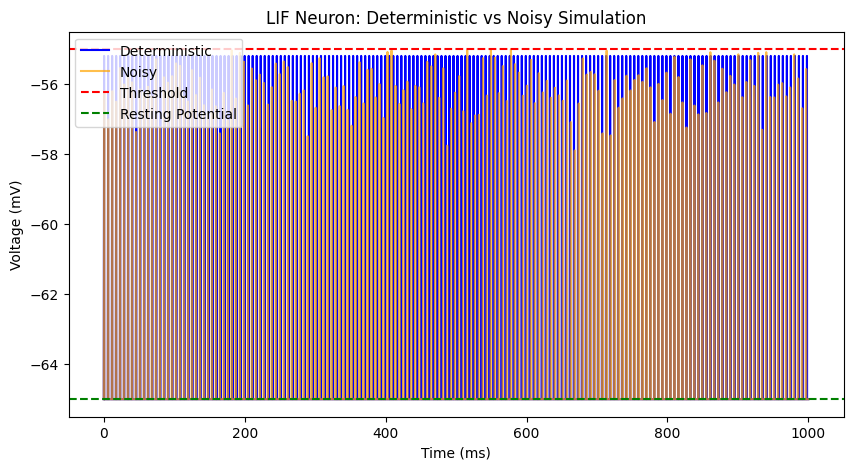

In [84]:
plt.figure(figsize=(10,5))
plt.plot(time*1000, V*1000, color='blue', label='Deterministic')
plt.plot(time*1000, V_noisy*1000, color='orange', alpha=0.7, label='Noisy')
plt.axhline(V_th*1000, color='r', linestyle='--', label='Threshold')
plt.axhline(V_rest*1000, color='g', linestyle='--', label='Resting Potential')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('LIF Neuron: Deterministic vs Noisy Simulation')
plt.legend()
plt.show()

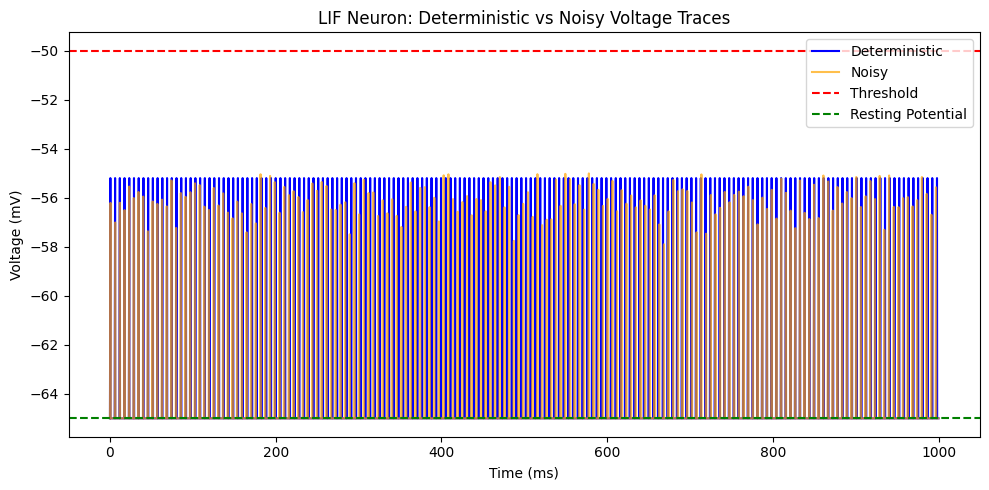

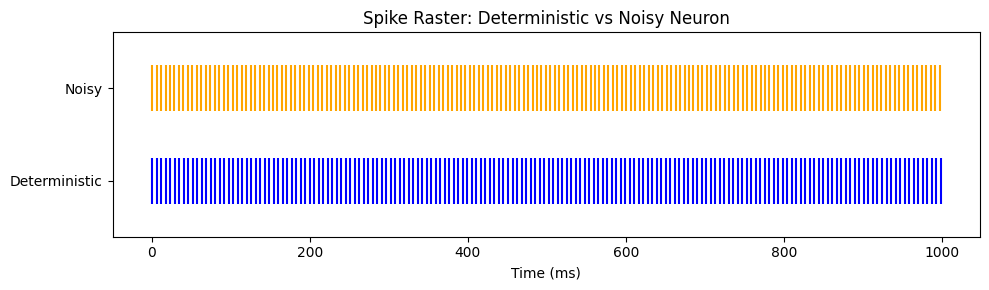

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load Data ---
df_det = pd.read_csv("data/lif_deterministic.csv")
df_noisy = pd.read_csv("data/lif_noisy.csv")

spikes_det = pd.read_csv("data/spikes_deterministic.csv")
spikes_noisy = pd.read_csv("data/spikes_noisy.csv")

# --- Plot 1: Voltage Trace Comparison ---
plt.figure(figsize=(10,5))
plt.plot(df_det["time_ms"], df_det["voltage_mV"], color='blue', label='Deterministic')
plt.plot(df_noisy["time_ms"], df_noisy["voltage_mV"], color='orange', alpha=0.7, label='Noisy')
plt.axhline(-50, color='r', linestyle='--', label='Threshold')
plt.axhline(-65, color='g', linestyle='--', label='Resting Potential')
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("LIF Neuron: Deterministic vs Noisy Voltage Traces")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Raster Plot (Spike Timing) ---
plt.figure(figsize=(10,3))
plt.eventplot([spikes_det["spike_times_ms"], spikes_noisy["spike_times_ms"]],
              colors=['blue','orange'], lineoffsets=[1,2], linelengths=0.5)
plt.yticks([1,2], ["Deterministic", "Noisy"])
plt.xlabel("Time (ms)")
plt.title("Spike Raster: Deterministic vs Noisy Neuron")
plt.tight_layout()
plt.show()


In [86]:
import numpy as np

# --- Compute statistics ---
def analyze_spikes(spike_times):
    isi = np.diff(spike_times)
    firing_rate = len(spike_times) / (spike_times.max() / 1000)  # spikes per second (Hz)
    mean_isi = np.mean(isi)
    std_isi = np.std(isi)
    cv = std_isi / mean_isi if mean_isi > 0 else np.nan
    return firing_rate, mean_isi, std_isi, cv

# Convert to numpy arrays
spike_det_arr = spikes_det["spike_times_ms"].to_numpy()
spike_noisy_arr = spikes_noisy["spike_times_ms"].to_numpy()

# Analyze both
rate_det, mean_isi_det, std_isi_det, cv_det = analyze_spikes(spike_det_arr)
rate_noisy, mean_isi_noisy, std_isi_noisy, cv_noisy = analyze_spikes(spike_noisy_arr)

# --- Print results ---
print("Spike Train Statistics")
print("--------------------------------------------")
print(f"Deterministic Neuron:")
print(f"  Firing rate: {rate_det:.2f} Hz")

print(f"  Coefficient of Variation (CV): {cv_det:.4f}")
print()
print(f"Noisy Neuron:")
print(f"  Firing rate: {rate_noisy:.2f} Hz")
print(f"  Coefficient of Variation (CV): {cv_noisy:.4f}")


Spike Train Statistics
--------------------------------------------
Deterministic Neuron:
  Firing rate: 176.34 Hz
  Coefficient of Variation (CV): 0.0000

Noisy Neuron:
  Firing rate: 177.55 Hz
  Coefficient of Variation (CV): 0.0105
